# EDA for 01_daily_merged_new.csv
This notebook performs Exploratory Data Analysis on the processed daily merged dataset.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [11]:
# Load data
DATA_PATH = '../../data/processed/01_daily_merged_clean.csv'
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,location_id,location_name,latitude,longitude,pm25,pm25_daily_std,pm25_min,pm25_max,pm25_count,...,ndvi_buffer_2km,ndvi_buffer_2km_std,ndvi_buffer_2km_p10,ndvi_buffer_2km_p90,ndvi_buffer_1km_winter,ndvi_buffer_1km_summer,sin_doy,cos_doy,sin_month,cos_month
0,2024-01-29,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,49.964286,2.430993,45.920000,53.020000,7,...,0.2443,0.1788,0.0665,0.5195,0.2297,0.2801,0.478434,0.878124,0.500000,0.866025
1,2024-01-30,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,55.806250,10.596282,36.860000,71.400000,24,...,0.2443,0.1788,0.0665,0.5195,0.2297,0.2801,0.493468,0.869764,0.500000,0.866025
2,2024-01-31,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,30.300000,10.179224,13.380000,47.460000,24,...,0.2443,0.1788,0.0665,0.5195,0.2297,0.2801,0.508356,0.861147,0.500000,0.866025
3,2024-02-01,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,19.106829,0.407932,18.561707,19.651951,6,...,0.2443,0.1788,0.0665,0.5195,0.2297,0.2801,0.523094,0.852275,0.866025,0.500000
4,2024-02-02,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,8.741250,2.056338,6.050000,12.010000,8,...,0.2443,0.1788,0.0665,0.5195,0.2297,0.2801,0.537677,0.843151,0.866025,0.500000


## Basic Information

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2585 entries, 0 to 2584
Columns: 153 entries, date to cos_month
dtypes: datetime64[ns](1), float64(121), int64(27), object(4)
memory usage: 3.0+ MB


In [13]:
df.describe()

,date,location_id,latitude,longitude,pm25,pm25_daily_std,pm25_min,pm25_max,pm25_count,co_mean,...,ndvi_buffer_2km,ndvi_buffer_2km_std,ndvi_buffer_2km_p10,ndvi_buffer_2km_p90,ndvi_buffer_1km_winter,ndvi_buffer_1km_summer,sin_doy,cos_doy,sin_month,cos_month
count,2585,2.585000e+03,2585.00000,2585.000000,2585.000000,2566.000000,2566.000000,2566.000000,2585.000000,2585.000000,...,2585.000000,2585.000000,2585.000000,2585.000000,2585.000000,2585.000000,2585.000000,2585.000000,2585.000000,2.585000e+03
mean,2025-07-03 10:28:21.818181632,3.475738e+06,21.02346,105.810664,42.828350,14.315233,22.741617,71.888499,20.188395,1488.110804,...,0.294823,0.197831,0.087227,0.595082,0.260378,0.303574,0.110237,0.082733,0.119194,4.651416e-02
min,2024-01-29 00:00:00,2.161292e+06,20.99330,105.740000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.225400,0.170300,0.066500,0.488300,0.222800,0.249900,-0.999999,-0.999979,-1.000000,-1.000000e+00
25%,2024-12-17 00:00:00,2.161292e+06,21.00520,105.794700,22.629583,6.151734,7.547857,36.749375,24.000000,759.025000,...,0.244300,0.178800,0.066500,0.519500,0.229700,0.280100,-0.638384,-0.536771,-0.500000,-5.000000e-01
50%,2025-09-07 00:00:00,2.161306e+06,21.01520,105.799900,34.235476,10.159643,16.295000,54.940000,24.000000,1182.354356,...,0.276700,0.193800,0.082200,0.581900,0.235700,0.280100,0.232243,0.125461,0.500000,6.123234e-17
75%,2026-01-28 00:00:00,4.946812e+06,21.04910,105.841800,55.336835,17.046680,31.318611,87.546052,24.000000,1580.919458,...,0.372400,0.216200,0.097800,0.683500,0.289600,0.316400,0.846029,0.735762,0.866025,5.000000e-01
max,2026-05-15 00:00:00,6.123215e+06,21.05000,105.944100,214.962287,164.771832,166.597333,496.580000,24.000000,35626.689394,...,0.378200,0.250000,0.113400,0.722600,0.314700,0.363300,0.999986,0.999991,1.000000,1.000000e+00
std,NaN,1.508406e+06,0.02076,0.057799,29.524636,14.472088,21.732163,58.367973,8.013998,2184.232858,...,0.058613,0.022646,0.017961,0.082665,0.036573,0.038401,0.731071,0.668520,0.732385,6.690461e-01


## Missing Values

In [14]:
missing_cols = df.isnull().sum()
missing_cols[missing_cols > 0].sort_values(ascending=False)

o3_std            389
o3_mean           389
pm25_daily_std     19
pm25_max           19
pm25_min           19
blh_mean            6
blh_min             6
blh_max             6
blh_morning         6
dtype: int64

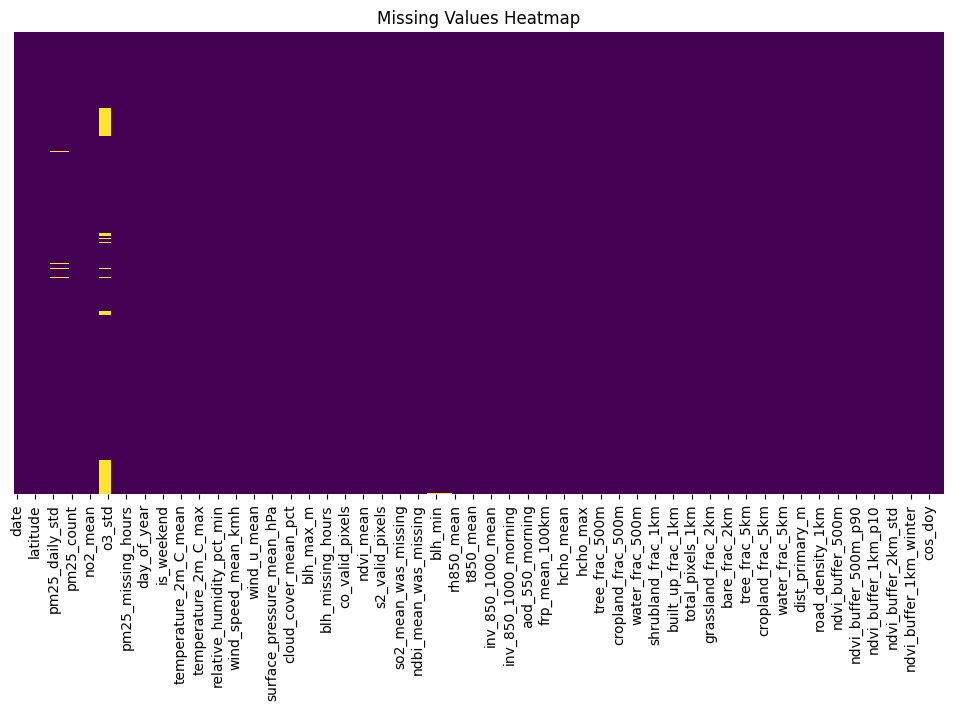

In [15]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## Target Variable Distribution (PM2.5)

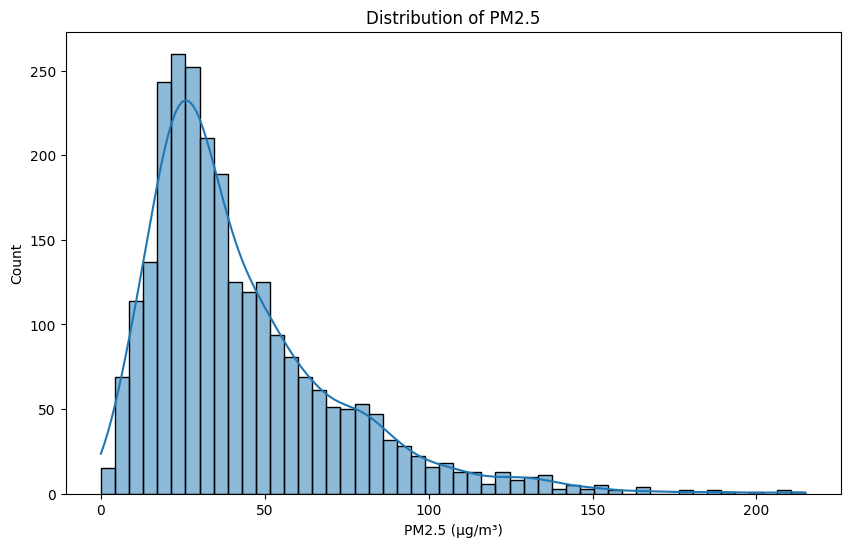

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['pm25'], bins=50, kde=True)
plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5 (µg/m³)')
plt.show()

## Temporal Analysis

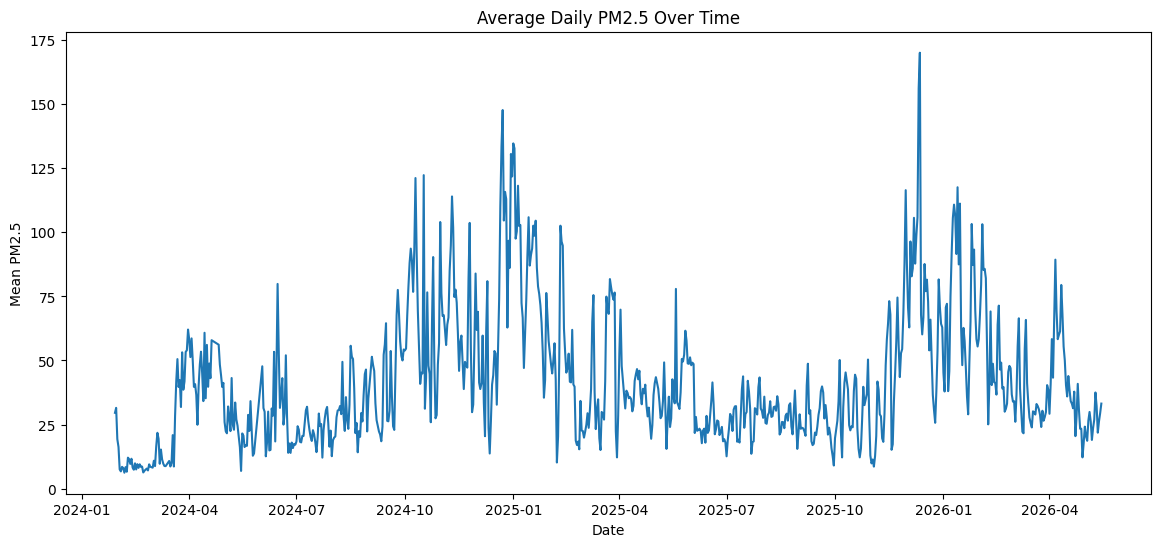

In [17]:
daily_mean = df.groupby('date')['pm25'].mean().reset_index()
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_mean, x='date', y='pm25')
plt.title('Average Daily PM2.5 Over Time')
plt.xlabel('Date')
plt.ylabel('Mean PM2.5')
plt.show()

## Spatial Analysis

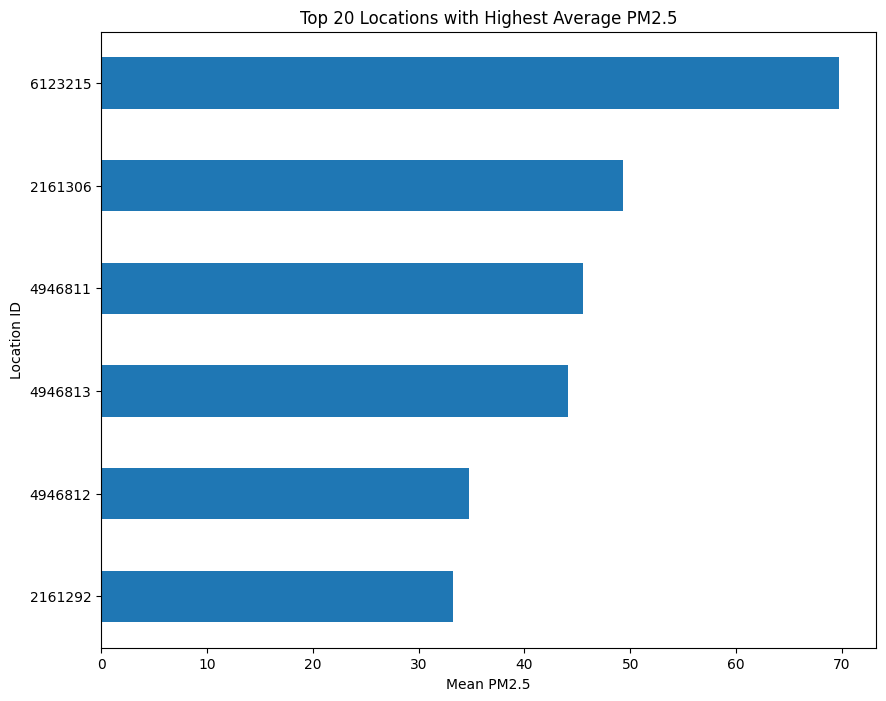

In [18]:
station_mean = df.groupby('location_id')['pm25'].mean().sort_values()
plt.figure(figsize=(10, 8))
station_mean.tail(20).plot(kind='barh')
plt.title('Top 20 Locations with Highest Average PM2.5')
plt.xlabel('Mean PM2.5')
plt.ylabel('Location ID')
plt.show()